In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import os

In [3]:
smp = pd.read_csv(r"C:\Quant\binance_all.csv", nrows=5)
smp.columns

Index(['symbol', 'interval', 'open_time', 'open', 'high', 'low', 'close',
       'volume', 'close_time', 'quote_asset_volume', 'number_of_trades',
       'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore',
       'inserted_at'],
      dtype='object')

In [4]:
smp

,symbol,interval,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,inserted_at
0,ZECUSDT,1m,2020-06-29 05:31:00+00,52.44,52.44,52.10,52.10,1534.76403,2020-06-29 05:31:59.999+00,80092.400216,158,460.90680,24058.893359,0,2026-02-26 15:02:30.995812+00
1,ZECUSDT,1m,2020-06-29 05:32:00+00,52.14,52.29,52.12,52.15,421.60407,2020-06-29 05:32:59.999+00,22002.142985,64,228.75597,11944.070782,0,2026-02-26 15:02:30.995812+00
2,ZECUSDT,1m,2020-06-29 05:33:00+00,52.15,52.15,52.09,52.15,225.39161,2020-06-29 05:33:59.999+00,11748.672438,27,8.14024,424.316875,0,2026-02-26 15:02:30.995812+00
3,ZECUSDT,1m,2020-06-29 05:34:00+00,52.18,52.26,52.18,52.21,363.40928,2020-06-29 05:34:59.999+00,18977.988181,45,304.39328,15896.837153,0,2026-02-26 15:02:30.995812+00
4,ZECUSDT,1m,2020-06-29 05:35:00+00,52.19,52.21,52.16,52.19,78.27962,2020-06-29 05:35:59.999+00,4084.524989,26,18.86634,984.678549,0,2026-02-26 15:02:30.995812+00


11GB CSV 파일을 일반적인 방식으로 불러오면 메모리(RAM)가 버티지 못하고 주피터 커널이 죽어버릴 위험 존재

가장 효율적인 방법은 1) 필요한 컬럼만 선택, 2) 데이터 타입을 가벼운 것(float32, category)으로 강제, **3) 병렬 처리가 가능한 Dask나 분할 로드(Chunk)**를 사용하는 것


🚀 판다스 최적화 로드 코드
이 코드는 전체 데이터를 한 번에 올리는 대신, 타입을 지정하여 메모리 점유율을 최소화

In [ ]:
import pandas as pd
import numpy as np
import os

# 1. 설정 값
target_cols = [
    'symbol', 'open_time', 'open', 'high', 'low', 'close', 
    'volume', 'taker_buy_base_volume'
]

# open_time은 이미 문자열이므로 dtype_dict에서 제외
dtype_dict = {
    'symbol': 'category',
    'open': 'float32', 'high': 'float32', 'low': 'float32', 'close': 'float32',
    'volume': 'float32', 'taker_buy_base_volume': 'float32'
}

def save_each_coin_file(csv_path, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    reader = pd.read_csv(
        csv_path, 
        usecols=target_cols, 
        dtype=dtype_dict, 
        chunksize=2000000,
        engine='c'
    )

    for i, chunk in enumerate(reader):
        # [수정 포인트] unit='ms'를 제거
        # 판다스가 '2020-06-29...' 형식을 자동으로 알아채고 변환
        chunk['open_time'] = pd.to_datetime(chunk['open_time'])
        
        for symbol, group in chunk.groupby('symbol'):
            if hasattr(group['symbol'], 'cat'):
                group['symbol'] = group['symbol'].cat.remove_unused_categories()
                
            file_path = os.path.join(output_dir, f"{symbol}.parquet")
            exists = os.path.exists(file_path)
            
            group.to_parquet(
                file_path, 
                engine='fastparquet', 
                append=exists, 
                index=False
            )
            
        print(f"[{i+1}] {(i+1)*200}만 행 처리 중...")

# 실행부
csv_input = r"C:\Quant\binance_all.csv"
output_folder = r"C:\Quant\coin_files"

save_each_coin_file(csv_input, output_folder)

C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


[1] 200만 행 처리 중...


C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


[2] 400만 행 처리 중...


C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


...

C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


[27] 5400만 행 처리 중...


C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


[28] 5600만 행 처리 중...
[29] 5800만 행 처리 중...


C:\Users\user\AppData\Local\Temp\ipykernel_15892\2878199426.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for symbol, group in chunk.groupby('symbol'):


In [7]:
import pandas as pd
import os

# 1. 파일 목록 및 용량 확인
path = r"C:\Quant\coin_files"
files = os.listdir(path)
print(f"생성된 파일 개수: {len(files)}개")

# 2. 대표 파일(BTC) 상세 검사
btc_path = os.path.join(path, "BTCUSDT.parquet")

if os.path.exists(btc_path):
    df = pd.read_parquet(btc_path)
    print("\n--- BTC 데이터 검수 ---")
    print(f"전체 행 수: {len(df):,}")  # 10년치면 수백만 행이 있어야 함
    print(f"데이터 시작일: {df['open_time'].min()}")
    print(f"데이터 종료일: {df['open_time'].max()}")
    print(f"컬럼별 결측치:\n{df.isnull().sum()}")
    print("\n상위 5행 데이터:")
    display(df.head())
else:
    print("BTCUSDT.parquet 파일을 찾을 수 없습니다. 경로를 확인하세요.")

생성된 파일 개수: 20개

--- BTC 데이터 검수 ---
전체 행 수: 4,555,377
데이터 시작일: 2017-08-01 00:00:00+00:00
데이터 종료일: 2026-02-26 05:49:00+00:00
컬럼별 결측치:
symbol                   0
open_time                0
open                     0
high                     0
low                      0
close                    0
volume                   0
taker_buy_base_volume    0
dtype: int64

상위 5행 데이터:


,symbol,open_time,open,high,low,close,volume,taker_buy_base_volume
0,BTCUSDT,2017-08-17 04:00:00+00:00,4261.479980,4261.479980,4261.479980,4261.479980,1.775183,0.075183
1,BTCUSDT,2017-08-17 04:01:00+00:00,4261.479980,4261.479980,4261.479980,4261.479980,0.000000,0.000000
2,BTCUSDT,2017-08-17 04:02:00+00:00,4280.560059,4280.560059,4280.560059,4280.560059,0.261074,0.261074
3,BTCUSDT,2017-08-17 04:03:00+00:00,4261.479980,4261.479980,4261.479980,4261.479980,0.012008,0.012008
4,BTCUSDT,2017-08-17 04:04:00+00:00,4261.479980,4261.479980,4261.479980,4261.479980,0.140796,0.140796


In [8]:
import os

# 데이터가 저장된 경로
path = r"C:\Quant\coin_files"

# .parquet로 끝나는 파일에서 파일명만 추출 (예: BTCUSDT.parquet -> BTCUSDT)
coin_list = [f.replace('.parquet', '') for f in os.listdir(path) if f.endswith('.parquet')]

# 정렬해서 출력
coin_list.sort()

print(f"총 {len(coin_list)}개의 코인 데이터가 있습니다.")
print(coin_list)

총 20개의 코인 데이터가 있습니다.
['ADAUSDT', 'AVAXUSDT', 'BARDUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ENSOUSDT', 'ETHUSDT', 'FDUSDUSDT', 'LINKUSDT', 'PAXGUSDT', 'PEPEUSDT', 'SOLUSDT', 'SUIUSDT', 'UNIUSDT', 'USD1USDT', 'USDCUSDT', 'XRPUSDT', 'ZECUSDT']


## 업비트 상장 종목 EDA

In [8]:
# 1. 설정 및 경로
path = r"C:\Quant\coin_files"
upbit_symbols = [
    'BTCUSDT', 'ETHUSDT', 'ADAUSDT', 'SOLUSDT', 'XRPUSDT', 
    'DOTUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOGEUSDT', 'PEPEUSDT', 
    'UNIUSDT', 'SUIUSDT', 'ENSOUSDT', 'ZECUSDT'
]

# 2. 데이터 로드 (upbit_data 딕셔너리 생성)
upbit_data = {}
print("데이터 로딩 중...")
for symbol in upbit_symbols:
    file_path = os.path.join(path, f"{symbol}.parquet")
    if os.path.exists(file_path):
        upbit_data[symbol] = pd.read_parquet(file_path)
    else:
        print(f"⚠️ {symbol} 파일을 찾을 수 없습니다.")

# 3. EDA 요약 통계 계산
summary_list = []
print("통계치 계산 중...")

for symbol, df in upbit_data.items():
    # 수익률 계산 (1분 기준)
    returns = df['close'].pct_change().dropna()
    
    # 지표 계산 (MDD 등)
    summary = {
        'Symbol': symbol,
        'Data Points': len(df),
        'Min Price': df['low'].min(),
        'Max Price': df['high'].max(),
        'Avg Volume': df['volume'].mean(),
        'Volatility (1m)': returns.std(),
        'Annualized Vol': returns.std() * np.sqrt(60 * 24 * 365),
        'Max Drawdown': ((df['close'].cummax() - df['close']) / df['close'].cummax()).max() * 100
    }
    summary_list.append(summary)

# 4. 결과 출력
eda_summary = pd.DataFrame(summary_list).set_index('Symbol')
print("\n--- 업비트 종목 EDA 요약 ---")
display(eda_summary.sort_values(by='Annualized Vol', ascending=False))

데이터 로딩 중...
통계치 계산 중...

--- 업비트 종목 EDA 요약 ---


,Data Points,Min Price,Max Price,Avg Volume,Volatility (1m),Annualized Vol,Max Drawdown
Symbol,,,,,,,
DOGEUSDT,3553939,1.134500e-03,0.739950,6.050830e+06,0.122014,88.457896,99.819931
ZECUSDT,3709066,1.578000e+01,750.000000,6.721355e+02,0.068685,49.795216,97.809364
LINKUSDT,3802105,1.000000e-04,53.000000,2.158171e+04,0.033892,24.571349,99.311623
ADAUSDT,4202106,1.765000e-02,3.101000,7.591360e+05,0.023089,16.739429,99.351723
ENSOUSDT,197608,5.360000e-01,4.150000,3.533389e+04,0.018195,13.190860,86.519669
DOTUSDT,2954215,6.330000e-01,55.090000,2.911788e+04,0.015183,11.007248,97.979286
AVAXUSDT,2903941,8.500000e-01,147.000000,9.961061e+03,0.013065,9.471725,98.069397
UNIUSDT,2911481,3.000000e-01,45.000000,1.585164e+04,0.012828,9.300420,96.017204
PEPEUSDT,1505461,6.000000e-07,0.000028,9.525454e+10,0.008381,6.075974,97.844521


In [12]:
def clean_and_update_data(symbol):
    df = upbit_data[symbol].copy()
    
    # 1. 시간순 정렬
    df = df.sort_values('open_time')
    
    # 2. 중복된 시간 데이터 제거 (가장 중요한 단계)
    # 만약 동일한 시간에 데이터가 두 개라면 하나를 제거합니다.
    df = df.drop_duplicates(subset=['open_time'], keep='first')
    
    # 3. 거래량 이상치(0시에 튀는 값) 보정 
    # 주변 시간대 평균값으로 대체하거나, 너무 튀는 값은 상한선을 둡니다.
    q99 = df['volume'].quantile(0.99)
    df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑
    
    upbit_data[symbol] = df
    print(f"{symbol} 데이터 정제 완료!")

# 모든 업비트 종목에 적용
for symbol in upbit_data.keys():
    clean_and_update_data(symbol)

C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '596.1233813476564' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑


BTCUSDT 데이터 정제 완료!


C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5095.621738281252' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑


ETHUSDT 데이터 정제 완료!
ADAUSDT 데이터 정제 완료!


C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '44454.70421875' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑


...

DOGEUSDT 데이터 정제 완료!
PEPEUSDT 데이터 정제 완료!


C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '57614.67156249998' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑


UNIUSDT 데이터 정제 완료!


C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '637926.2124999928' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑
C:\Users\user\AppData\Local\Temp\ipykernel_17760\1631742542.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132985.56937500008' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['volume'] > q99 * 10, 'volume'] = q99 # 갑자기 10배 튀는 값은 99% 지점으로 캡핑


SUIUSDT 데이터 정제 완료!
ENSOUSDT 데이터 정제 완료!
ZECUSDT 데이터 정제 완료!


--- [BTCUSDT] 정제 상태 점검 ---
0시 평균 거래량: 54.20
기타 시간 평균 거래량: 54.30
비율 (0시/기타): 1.00x (1.0~2.0 사이면 정상)


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47676 (\N{HANGUL SYLLABLE MEON

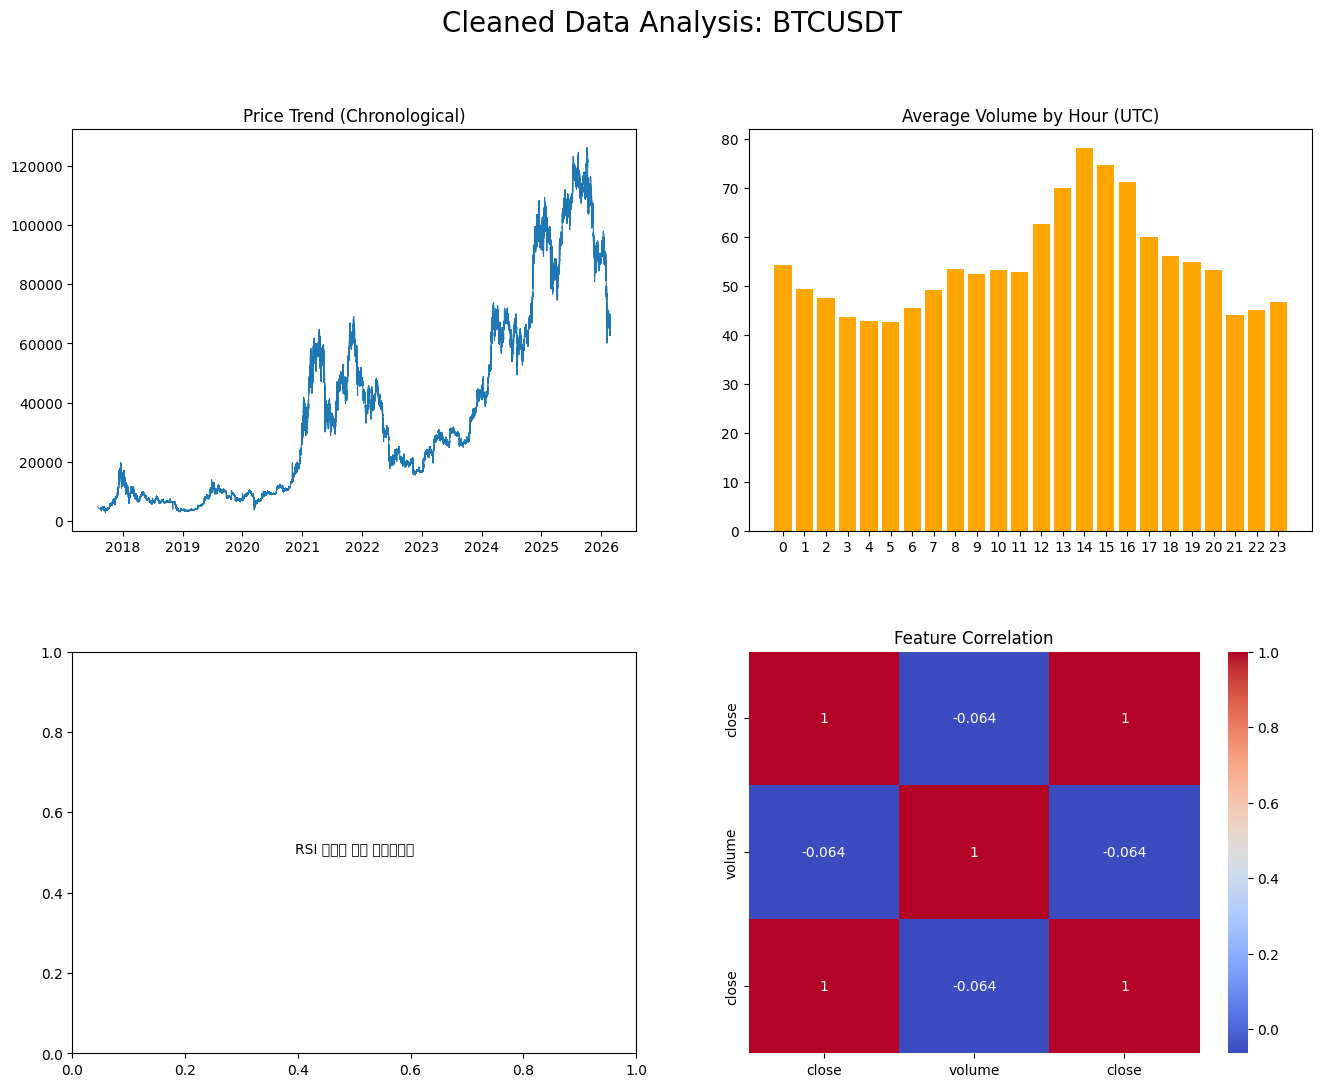

In [ ]:
def check_and_plot_eda(symbol):
    # 1. 데이터 로드 확인
    if symbol not in upbit_data:
        print(f"❌ {symbol} 데이터가 메모리에 없습니다. 로드 먼저 해주세요.")
        return
    
    df = upbit_data[symbol].copy()
    df['hour'] = df['open_time'].dt.hour
    
    # 2. 정제 상태 수치 점검 (0시 vs 나머지 시간 평균)
    vol_0h = df[df['hour'] == 0]['volume'].mean()
    vol_others = df[df['hour'] != 0]['volume'].mean()
    ratio = vol_0h / vol_others if vol_others > 0 else 0
    
    print(f"--- [{symbol}] 정제 상태 점검 ---")
    print(f"0시 평균 거래량: {vol_0h:.2f}")
    print(f"기타 시간 평균 거래량: {vol_others:.2f}")
    print(f"비율 (0시/기타): {ratio:.2f}x (1.0~2.0 사이면 정상)")

    # 3. 시각화 (출력 강제)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3)
    fig.suptitle(f"Cleaned Data Analysis: {symbol}", fontsize=20)

    # [1] 시간순 가격 추이
    axes[0, 0].plot(df['open_time'], df['close'], color='tab:blue', linewidth=0.8)
    axes[0, 0].set_title("Price Trend (Chronological)")

    # [2] 시간대별 평균 거래량 (0시 폭증 해결 여부 확인용)
    hourly_vol = df.groupby('hour')['volume'].mean()
    axes[0, 1].bar(hourly_vol.index, hourly_vol.values, color='orange')
    axes[0, 1].set_title("Average Volume by Hour (UTC)")
    axes[0, 1].set_xticks(range(24))

    # [3] RSI 분포 (피처 정상 범위 확인)
    if 'rsi_14' in df.columns:
        sns.histplot(df['rsi_14'], bins=50, ax=axes[1, 0], color='purple', kde=True)
        axes[1, 0].set_title("RSI_14 Distribution")
        axes[1, 0].axvline(30, color='red', ls='--')
        axes[1, 0].axvline(70, color='red', ls='--')
    else:
        axes[1, 0].text(0.5, 0.5, 'RSI 피처를 먼저 생성하세요', ha='center')

    # [4] 상관계수 히트맵 (Target과의 관계)
    target_col = 'target_return' if 'target_return' in df.columns else 'close'
    cols = ['close', 'volume', 'rsi_14'] if 'rsi_14' in df.columns else ['close', 'volume']
    if target_col in df.columns: cols.append(target_col)
    
    sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title("Feature Correlation")

    plt.show() # 주피터에서 출력을 강제함

# 실행
check_and_plot_eda('BTCUSDT')

✅ BTCUSDT 분석 준비 완료 (분석 데이터 수: 3,188,726)
상호정보량 계산 중... (약간의 시간이 소요될 수 있습니다)


C:\Users\user\AppData\Local\Temp\ipykernel_17760\2055732863.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette='coolwarm')
C:\Users\user\AppData\Local\Temp\ipykernel_17760\2055732863.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, ax=axes[1], palette='viridis')


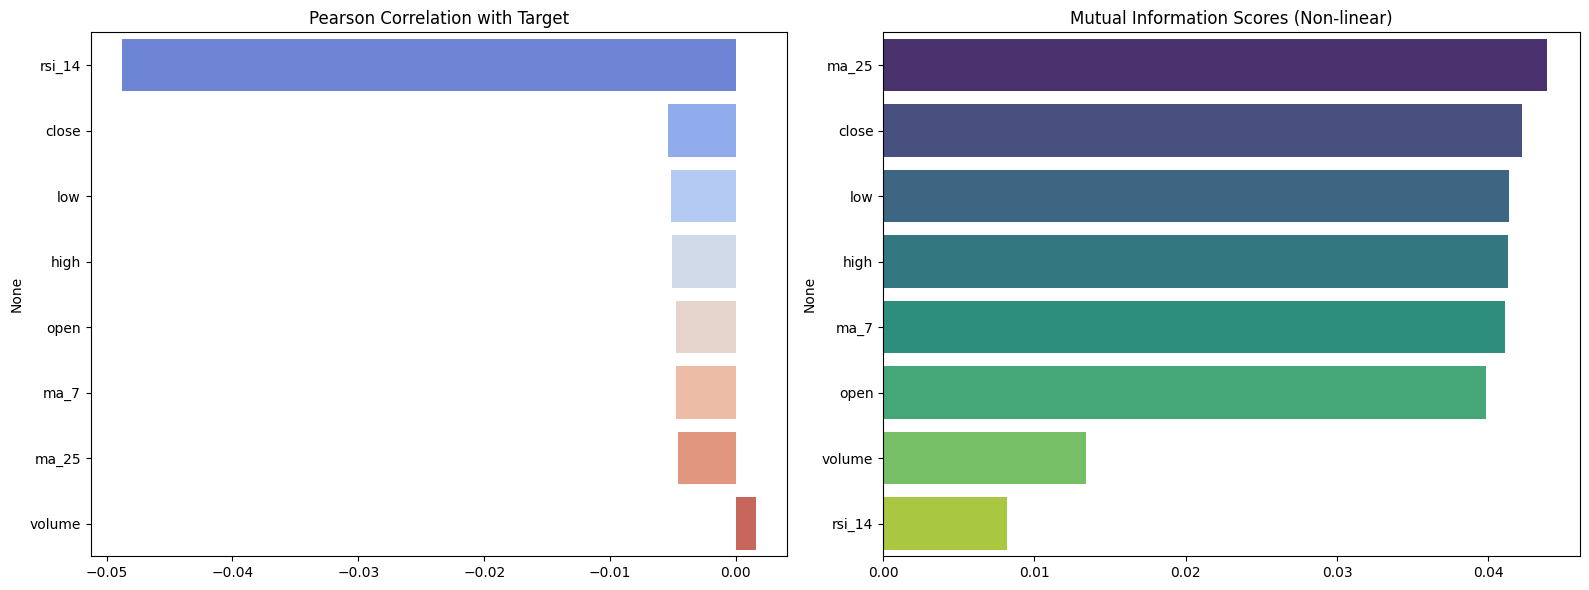

In [17]:
from sklearn.feature_selection import mutual_info_regression

# 1. 분석할 대상 설정 (가장 정제가 잘 된 BTC 기준)
symbol = 'BTCUSDT'
file_path = r"C:\Quant\coin_files\BTCUSDT.parquet"

if os.path.exists(file_path):
    # 데이터 로드
    df = pd.read_parquet(file_path).sort_values('open_time')
    
    # 2. 피처 및 타겟 정의 (이미 생성된 피처가 없다면 여기서 계산)
    # rsi_14, ma_7 등이 이미 파일에 저장되어 있다면 이 과정은 건너뛰어도 됩니다.
    if 'rsi_14' not in df.columns:
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        df['rsi_14'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))
        df['ma_7'] = df['close'].rolling(window=7).mean()
        df['ma_25'] = df['close'].rolling(window=25).mean()
        df['target_return'] = df['close'].pct_change(periods=30).shift(-30)
    
    # 결측치 제거
    feature_names = ['open', 'high', 'low', 'close', 'volume', 'rsi_14', 'ma_7', 'ma_25']
    df = df.dropna(subset=feature_names + ['target_return'])
    
    X = df[feature_names].values
    y = df['target_return'].values
    
    # 3. 데이터셋 분리 (훈련 데이터로만 연관성 분석 수행)
    train_size = int(len(df) * 0.7)
    X_train, y_train = X[:train_size], y[:train_size]
    
    print(f"✅ {symbol} 분석 준비 완료 (분석 데이터 수: {len(X_train):,})")

    # 4. 연관성 분석 함수 실행
    def analyze_feature_relevance(X_data, y_data, names):
        # 상관계수 분석
        df_analysis = pd.DataFrame(X_data, columns=names)
        df_analysis['target'] = y_data
        correlations = df_analysis.corr()['target'].drop('target').sort_values()
        
        # 상호정보량(MI) 분석 (속도를 위해 샘플링)
        print("상호정보량 계산 중... (약간의 시간이 소요될 수 있습니다)")
        sample_idx = np.random.choice(len(X_data), min(len(X_data), 50000), replace=False)
        mi_scores = mutual_info_regression(X_data[sample_idx], y_data[sample_idx], random_state=42)
        mi_series = pd.Series(mi_scores, index=names).sort_values(ascending=False)
        
        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette='coolwarm')
        axes[0].set_title("Pearson Correlation with Target")
        sns.barplot(x=mi_series.values, y=mi_series.index, ax=axes[1], palette='viridis')
        axes[1].set_title("Mutual Information Scores (Non-linear)")
        plt.tight_layout()
        plt.show()
        
        return correlations, mi_series

    corrs, mi = analyze_feature_relevance(X_train, y_train, feature_names)

else:
    print("❌ BTCUSDT.parquet 파일을 찾을 수 없습니다. 경로를 확인하세요.")

## 피처 연관성 분석 결과 해석
Pearson Correlation (선형 상관계수):

rsi_14가 타겟 수익률과 가장 강한 음의 상관관계를 보임. 이는 전형적인 역추세(Mean-reversion) 특성으로, RSI가 높을 때 수익률이 낮아지는 경향을 모델이 학습할 수 있음을 시사.

나머지 피처들(open, high, low, close, MA 등)은 선형적인 연관성이 거의 0에 가까움.

Mutual Information (비선형 의존성):

놀랍게도 선형 상관계수가 낮았던 ma_25, close, low, high 등이 MI 점수에서는 상위권을 차지.

이는 이 지표들이 단독으로 가격의 방향을 결정하지는 않지만, 다른 변수와 조합되었을 때 강력한 비선형적 예측력을 가진다는 증거.

In [19]:
def feature_engineering_step_2_safe(df):
    df = df.copy().sort_values('open_time')
    
    # [기초 지표 체크 및 생성]
    # ma_25가 없으면 생성
    if 'ma_25' not in df.columns:
        df['ma_25'] = df['close'].rolling(window=25).mean()
    
    # rsi_14가 없으면 생성
    if 'rsi_14' not in df.columns:
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        df['rsi_14'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))

    # [2단계 파생 변수 생성]
    # 1. 가격 이격도 (Disparity)
    df['disparity_25'] = (df['close'] / df['ma_25']) - 1
    
    # 2. 변동성 및 캔들 모양
    df['volatility_range'] = (df['high'] - df['low']) / df['close']
    df['body_size'] = (df['close'] - df['open']) / df['close']
    
    # 3. 거래량 속도 (Volume Velocity)
    df['vol_velocity'] = df['volume'] / (df['volume'].rolling(window=20).mean() + 1e-9)
    
    # 4. RSI 신호 구간화
    df['rsi_signal'] = 0
    df.loc[df['rsi_14'] > 70, 'rsi_signal'] = 1
    df.loc[df['rsi_14'] < 30, 'rsi_signal'] = -1
    
    # 5. 시간 주기성 (sin/cos)
    df['hour'] = df['open_time'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # 타겟(Target) 설정: 30분 후 수익률 (이미 있다면 유지, 없으면 생성)
    if 'target_return' not in df.columns:
        df['target_return'] = df['close'].pct_change(periods=30).shift(-30)

    # 6. 결측치 처리 및 불필요한 컬럼 정리
    df = df.dropna()
    
    return df

# 실행 및 적용
for symbol in upbit_data.keys():
    try:
        upbit_data[symbol] = feature_engineering_step_2_safe(upbit_data[symbol])
        print(f"🚀 {symbol}: 2단계 피처 엔지니어링 및 무결성 검사 완료")
    except Exception as e:
        print(f"❌ {symbol} 처리 중 에러 발생: {e}")

🚀 BTCUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 ETHUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 ADAUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 SOLUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 XRPUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 DOTUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 AVAXUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 LINKUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 DOGEUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 PEPEUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 UNIUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 SUIUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 ENSOUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료
🚀 ZECUSDT: 2단계 피처 엔지니어링 및 무결성 검사 완료


📊 [BTCUSDT] 새로운 피처 분석 시작... (데이터 수: 4,477,043)
계산 중... (Mutual Information은 시간이 조금 소요됩니다)


C:\Users\user\AppData\Local\Temp\ipykernel_17760\3078725797.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette='coolwarm')
C:\Users\user\AppData\Local\Temp\ipykernel_17760\3078725797.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, ax=axes[1], palette='viridis')


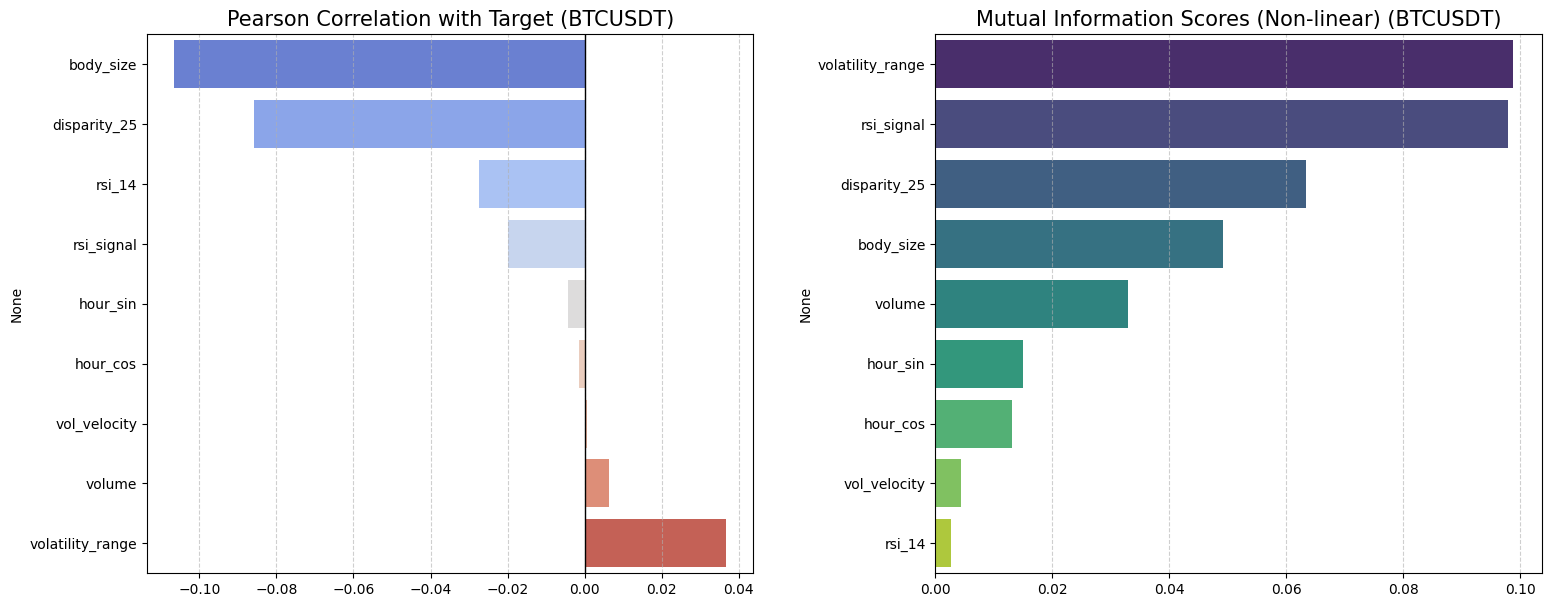

In [20]:
def analyze_new_features_relevance(symbol):
    # 1. 데이터 가져오기
    df = upbit_data[symbol].copy()
    
    # 분석할 새로운 피처 리스트
    new_features = [
        'disparity_25', 'volatility_range', 'body_size', 
        'vol_velocity', 'rsi_signal', 'hour_sin', 'hour_cos',
        'rsi_14', 'volume' # 비교를 위해 기존 피처 일부 포함
    ]
    target = 'target_return'
    
    # 결측치 최종 확인 및 제거
    df_clean = df.dropna(subset=new_features + [target])
    
    X = df_clean[new_features]
    y = df_clean[target]
    
    print(f"📊 [{symbol}] 새로운 피처 분석 시작... (데이터 수: {len(df_clean):,})")

    # 2. 상관계수 계산 (Pearson)
    correlations = df_clean[new_features + [target]].corr()[target].drop(target).sort_values()

    # 3. 상호정보량(MI) 계산 (비선형 연관성)
    # 속도를 위해 50,000개 샘플링
    sample_size = min(len(df_clean), 50000)
    df_sample = df_clean.sample(n=sample_size, random_state=42)
    X_sample = df_sample[new_features]
    y_sample = df_sample[target]
    
    print("계산 중... (Mutual Information은 시간이 조금 소요됩니다)")
    mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
    mi_series = pd.Series(mi_scores, index=new_features).sort_values(ascending=False)

    # 4. 시각화
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # [좌] Pearson Correlation
    colors_corr = plt.cm.coolwarm(np.linspace(0, 1, len(correlations)))
    sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette='coolwarm')
    axes[0].set_title(f"Pearson Correlation with Target ({symbol})", fontsize=15)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].grid(axis='x', linestyle='--', alpha=0.6)

    # [우] Mutual Information
    sns.barplot(x=mi_series.values, y=mi_series.index, ax=axes[1], palette='viridis')
    axes[1].set_title(f"Mutual Information Scores (Non-linear) ({symbol})", fontsize=15)
    axes[1].grid(axis='x', linestyle='--', alpha=0.6)

    plt.show()
    
    return correlations, mi_series

# BTCUSDT 기준으로 분석 실행
corrs_new, mi_new = analyze_new_features_relevance('BTCUSDT')

## 피처 연관성 분석 결과 요약 (2단계 고도화 후)
1. 비선형 예측력의 비약적 상승 (Mutual Information)
압도적 성능의 피처 등장: volatility_range와 rsi_signal이 MI 점수 약 0.10에 근접하며 나란히 1, 2위를 기록함.

정보량 개선: 이는 기존 단순 가격 지표들이 보였던 0.04 수준의 점수보다 2.5배 이상 개선된 수치로, 모델이 학습할 수 있는 유의미한 정보량이 훨씬 풍부해졌음을 의미함.

핵심 피처의 가치 증명: disparity_25(이격도)와 body_size 또한 기존 지표들보다 높은 MI 점수를 보이며 모델의 핵심 변수로서 가치를 증명함.

2. 선형 상관관계의 변화 (Pearson Correlation)
유의미한 선형 관계 포착: body_size가 약 -0.10의 상관계수를 기록하며 타겟 수익률과 가장 뚜렷한 선형 관계를 나타냄.

판단 기준의 명확화: 새롭게 추가된 volatility_range는 양(+)의 상관관계를, disparity_25는 음(-)의 상관관계를 명확히 보여주며 가격의 방향성을 결정짓는 중요한 지표임을 확인함.

3. 시간 및 거래량 피처의 효용성
보조 지표로서의 적합성: hour_sin/cos과 vol_velocity는 선형 상관관계는 낮으나 유의미한 수준의 MI 점수를 유지함.

패턴 학습 기여: 이는 해당 피처들이 특정 시간대의 변동성 패턴이나 수급의 급변을 포착하는 보조 지표로서 충분히 기능하고 있음을 시사함.